# 27_model_cnn_lstm_ae_CHS

- 목적: 평가 윈도우와 같은 원신호 윈도우를 **통째로 복원**하는 CNN+LSTM 오토인코더로 정상 패턴을 학습하고, 복원 오차(채널별 분해 포함)를 이상 점수로 쓴다. 24~26(예측·그래프·분포 계열)과 학습 목표가 다른 **복원 계열** 1종을 모델 비교에 추가하고, 선형 대조군(`pca_raw_ae`)·입력 변형 ablation·세그먼트 집계·채널 기여를 함께 본다.
- 입력: `data/raw`(없으면 zip 자동 추출) → `preprocess.preprocess()` 세그먼트 배열, `data/processed/11_window_features.parquet`의 윈도우 키(`seg_uid`, `t_start`, `win_s`)·`fold`·`block`·`state`·등급(사후 해석용)
- 출력: `figures/27_model_cnn_lstm_ae_CHS/`, `results/27_model_cnn_lstm_ae_CHS/`(`metrics.csv`·`cv_scores.csv`·`error_cases.csv`·`scores.csv`·`ablation_variants.csv`·`segment_aggregation.csv`·`channel_attribution.csv`), `models/27_model_cnn_lstm_ae_CHS/`(가중치, git 제외)
- 담당: CHS
- 심사 대응: 2번(복원 계열 모델 + 선형 대조군 비교), 3번(채널 기여로 FN·FP 원인 설명), 5번(채널 불일치·사인 잔차 파생 채널), 6번(seed·가중치 저장, 윈도우 점수 `scores.csv`로 31 재현)

## 원칙 (설계서 §1·§6 요약)

| 항목 | 내용 |
|---|---|
| 입력 | 표준 전처리 결과의 윈도우 `(W, C)` — 1초 = 10샘플, 2초 = 20샘플. 금지: 원시값·DC·절대 시간·`state`·`label`·`src` |
| 구조 | Conv1d(C→16)·ReLU → Conv1d(16→32)·ReLU → LSTM(32→32) 마지막 은닉 → Linear(32→d=8)=z → z를 W번 반복 → LSTM(8→32) → Linear(32→C) |
| 학습 | MSE, Adam 1e-3, **batch 64, epochs 200**(고정), seed 0·1·2 (T3 변형 4종은 seed 0). train 정상 **세그먼트** 10%는 손실 모니터링 전용(선택에 쓰지 않음) |
| 점수 | e_c = mean_t (x̂−x)² / σ_c² (σ_c = train 복원 잔차 채널 sd), 점수 = mean_c e_c. e_c를 채널 기여로 저장 |
| 정규화·임계 | 채널 평균·표준편차, σ_c, 임계(q99)는 모두 **train 정상**에서만. 라벨로 하이퍼파라미터 선택 금지(d·epochs·batch 고정) |
| 분할 | `group_kfold_seg`(fold 0~4) + `time_block`(k=1~4) = 9분할, 윈도우 1·2초 |
| 선형 대조군 | `pca_raw_ae`: 같은 윈도우 벡터에 PCA(성분 8) 복원. CNN+LSTM이 이를 못 넘으면 비선형·시간 구조의 이득이 없다는 뜻 |
| 한계 | 이상 17 세그먼트 = 이벤트 1건, 날짜 = 라벨. AUC 1.0 근처는 일반화 주장이 아니라 이 이벤트에서의 관측값 |

**학습량 조정(설계서 §2의 epochs 40·batch 256 → 200·64)**: 설계 초안 값은 과소학습이었다. fold 0·1초·all3 probe에서 ep40·b256은 AUC 0.8733, train MSE 0.534(손실이 가파르게 하강 중), ep150·b64는 0.9935 / 0.199, ep300·b64는 0.9981 / 0.136이었고 모니터 손실 최저 epoch이 모두 마지막 epoch이라 과적합 없이 아직 수렴 전이었다. 조정 기준은 train·monitor 정상 손실의 수렴뿐이며 라벨·AUC로 고르지 않았다(probe의 AUC는 참고 기록). 이에 따라 200·64를 고정했다.

운전 상태 번호: 0 = 고부하, 1 = 저부하. 파일명 규칙: 0x 진단 · 1x 전처리·피처 · 2x 모델 · 3x 분석

In [1]:
import sys, warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
from matplotlib.ticker import FuncFormatter
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "27_model_cnn_lstm_ae_CHS"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"font.family": "Malgun Gothic", "axes.unicode_minus": False, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.color": "#e5e4e0", "axes.axisbelow": True,
                     "font.size": 9, "mathtext.fontset": "dejavusans"})
import benchmark_jiw as B      # 호출만 (iter_splits·load_inputs·to_metrics·baseline_table)
import models_chs as M
import evaluate as ev

WIN_LIST = (1.0, 2.0)
SEEDS = (0, 1, 2)
ABL_SEEDS = (0,)           # T3 변형 4종은 seed 0만 (설계서 §6 시간 대응, 마크다운에 명시)
D, EPOCHS = 8, 200         # d·epochs 고정, batch 64는 모듈 기본값 (손실 수렴 기준, 라벨 미사용)
RETRAIN = False            # models/27_model_cnn_lstm_ae_CHS/ 가중치가 있으면 불러와 평가만 한다
PROGRESS = False
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT), "device:", M.DEVICE)

27_model_cnn_lstm_ae_CHS figures\27_model_cnn_lstm_ae_CHS results\27_model_cnn_lstm_ae_CHS device: cpu


## 1. 데이터와 평가 가능 범위

세그먼트 길이 < 윈도우 길이인 세그먼트는 윈도우가 없어 평가에서 제외된다(kickoff §2). 1초 기준 이상 17/21 세그먼트가 평가 대상이며, 이상 세그먼트 3·19·20은 모두 포함된다.

In [2]:
segs, W = B.load_inputs()
cov = W.groupby(["win_s", "label"]).size().unstack().rename(columns={0: "정상 윈도우", 1: "이상 윈도우"})
cov["이상 세그먼트(윈도우 있음)"] = W[W.label == 1].groupby("win_s")["seg_uid"].nunique()
print("세그먼트", len(segs))
cov.loc[list(WIN_LIST)]

세그먼트 620


label,정상 윈도우,이상 윈도우,이상 세그먼트(윈도우 있음)
win_s,,,
1.0,3264,96,17
2.0,2254,63,13


## 2. T1 — 윈도우 단위 성능 (all3 입력, 1·2초 × 9분할 × seed 0·1·2)

`cnn_lstm_ae`와 선형 대조군 `pca_raw_ae`를 같은 분할·같은 임계(train 정상 q99)로 평가한다. PCA는 결정적이라 seed 간 값이 같다(행 구조만 통일).

In [3]:
T0 = time.time()
CV, SC = [], {}
for model in ["cnn_lstm_ae", "pca_raw_ae"]:
    for w in WIN_LIST:
        cv, sc = M.run_variant(segs, W, "all3", w, model=model, seeds=SEEDS, d=D, epochs=EPOCHS,
                               retrain=RETRAIN, nb=NB, progress=PROGRESS)
        CV.append(cv); SC[cv["model_id"].iloc[0]] = sc
        print(cv["model_id"].iloc[0], "runs", len(cv), "params", int(cv["n_params"].iloc[0]),
              "학습 초 합", round(cv["sec"].sum(), 1), cv["status"].value_counts().to_dict())
print("T1 경과(초)", round(time.time() - T0, 1))

cnn_lstm_ae_all3_w1s runs 27 params 15915 학습 초 합 1417.4 {'trained': 27}


cnn_lstm_ae_all3_w2s runs 27 params 15915 학습 초 합 1279.5 {'trained': 27}


pca_raw_ae_all3_w1s runs 27 params 240 학습 초 합 0.0 {'trained': 27}


pca_raw_ae_all3_w2s runs 27 params 480 학습 초 합 0.0 {'trained': 27}
T1 경과(초) 2700.5


## 3. T3 — 입력 변형 ablation (CNN+LSTM, 1초 × 9분할, **seed 0만**)

학습량 증가(epochs 200, batch 64)로 fit당 시간이 길어져 설계서 §6에 따라 변형 4종은 seed 0만 돌렸다. all3·`pca_raw_ae`는 seed 0·1·2를 유지하므로 ablation 표의 all3 행(seed 3개 평균)과 변형 행(seed 1개)은 seed 수가 다르다.

| variant | 채널 | 목적 |
|---|---|---|
| `vib2` | AI0, AI1 | 전류(에일리어싱·날짜 교란 후보) 없이도 잡히는가 |
| `cur1` | AI2 | 전류 단독. AUC≈1.0이면 날짜 교란 의심 |
| `all3+res` | + AI2 − 세그먼트 사인 피팅값 | 도메인 파생 채널. 세그먼트 전체 피팅이라 **ablation 전용**, 기본 성능과 분리 해석 (모델 이름은 `all3_res`) |
| `all3_zwin` | 3채널 윈도우 내 z-score | 형상만(스케일 불변). 진동 게인 동일성 미확인(03 A-2) 대비 |

In [4]:
T1 = time.time()
for v in ["vib2", "cur1", "all3+res", "all3_zwin"]:
    cv, sc = M.run_variant(segs, W, v, 1.0, model="cnn_lstm_ae", seeds=ABL_SEEDS, d=D, epochs=EPOCHS,
                           retrain=RETRAIN, nb=NB, progress=PROGRESS)
    CV.append(cv); SC[cv["model_id"].iloc[0]] = sc
    print(cv["model_id"].iloc[0], "runs", len(cv), "학습 초 합", round(cv["sec"].sum(), 1), cv["status"].value_counts().to_dict())
print("T3 경과(초)", round(time.time() - T1, 1))

cv_all = pd.concat(CV, ignore_index=True)
n_fit = len(cv_all[cv_all["model"] == "cnn_lstm_ae"])
print("전체 run(분할×seed) 수", len(cv_all), "/ CNN+LSTM 학습 fit 수", n_fit,
      "/ PCA fit 수", len(cv_all) - n_fit)
print("총 학습 시간(초, 저장된 학습 초 합)", round(cv_all["sec"].sum(), 1),
      "= CNN+LSTM", round(cv_all.loc[cv_all["model"] == "cnn_lstm_ae", "sec"].sum(), 1),
      "+ PCA", round(cv_all.loc[cv_all["model"] == "pca_raw_ae", "sec"].sum(), 1))
print("파라미터 수 CNN+LSTM(all3)", int(cv_all.loc[cv_all.model_id == "cnn_lstm_ae_all3_w1s", "n_params"].iloc[0]),
      "/ PCA", int(cv_all.loc[cv_all.model_id == "pca_raw_ae_all3_w1s", "n_params"].iloc[0]))

cnn_lstm_ae_vib2_w1s runs 9 학습 초 합 484.6 {'trained': 9}


cnn_lstm_ae_cur1_w1s runs 9 학습 초 합 546.1 {'trained': 9}


cnn_lstm_ae_all3_res_w1s runs 9 학습 초 합 568.0 {'trained': 9}


cnn_lstm_ae_all3_zwin_w1s runs 9 학습 초 합 576.0 {'trained': 9}
T3 경과(초) 2185.7
전체 run(분할×seed) 수 144 / CNN+LSTM 학습 fit 수 90 / PCA fit 수 54
총 학습 시간(초, 저장된 학습 초 합) 4871.6 = CNN+LSTM 4871.6 + PCA 0.0
파라미터 수 CNN+LSTM(all3) 15915 / PCA 240


## 4. 결과 저장과 요약 (`metrics.csv`·`cv_scores.csv`)

`metrics.csv` = 공통 7열 + `win_s, thr, n_out_seg, n_detected, felt_delay_median_s`. fold 행은 seed 평균, `fold="mean"` 행은 fold 평균. 모델 이름은 24~26과 같은 `<모델>_<변형>_w<초>s` 형식이다.

In [5]:
metrics = B.to_metrics(cv_all)
metrics.to_csv(RES / "metrics.csv", index=False)
cv_all.to_csv(RES / "cv_scores.csv", index=False)
print("metrics", metrics.shape, "cv_scores", cv_all.shape)
cols = ["model", "win_s", "split", "auc", "fpr_sample", "fpr_segment", "delay_median_s", "felt_delay_median_s", "n_detected", "n_out_seg"]
ref = B.baseline_table()
ref = ref[ref["model"].isin(B.BASELINE_RULES) & ref["win_s"].isin(WIN_LIST)][cols]
mine = metrics[metrics["fold"] == "mean"][cols]
cmp = pd.concat([ref, mine]).sort_values(["win_s", "split", "auc"], ascending=[True, True, False]).round(4).reset_index(drop=True)
cmp

metrics (88, 12) cv_scores (144, 20)


,model,win_s,split,auc,fpr_sample,fpr_segment,delay_median_s,felt_delay_median_s,n_detected,n_out_seg
0,cnn_lstm_ae_cur1_w1s,1.0,group_kfold_seg,1.0000,0.0145,0.0666,0.90,8.858,3.4000,3.4
1,cnn_lstm_ae_all3_res_w1s,1.0,group_kfold_seg,1.0000,0.0304,0.0979,0.90,8.858,3.4000,3.4
2,pca_raw_ae_all3_w1s,1.0,group_kfold_seg,0.9995,0.0109,0.0413,0.90,8.858,3.4000,3.4
3,cnn_lstm_ae_all3_zwin_w1s,1.0,group_kfold_seg,0.9994,0.0260,0.1482,0.90,8.858,3.4000,3.4
4,cnn_lstm_ae_all3_w1s,1.0,group_kfold_seg,0.9927,0.0191,0.0765,0.90,8.858,3.1333,3.4
5,cnn_lstm_ae_vib2_w1s,1.0,group_kfold_seg,0.9556,0.0239,0.0750,0.90,8.858,2.8000,3.4
6,rule3_rms_state_dir,1.0,group_kfold_seg,0.8696,0.0138,0.0358,0.95,8.908,2.8000,3.4
7,rule1_rms_ai0,1.0,group_kfold_seg,0.7864,0.0109,0.0395,0.95,8.908,2.8000,3.4
8,cnn_lstm_ae_cur1_w1s,1.0,time_block,1.0000,0.0215,0.1031,0.90,8.858,17.0000,17.0
9,cnn_lstm_ae_all3_res_w1s,1.0,time_block,1.0000,0.0455,0.1263,0.90,8.858,17.0000,17.0


In [6]:
# 1초·kfold/time_block 평균 한눈에 (fold 평균, seed 평균)
one = metrics[(metrics["fold"] == "mean") & (metrics["win_s"] == 1.0)]
tab = one.pivot_table(index="model", columns="split", values=["auc", "fpr_segment", "n_detected"]).round(4)
tab

auc                fpr_segment  \
split                     group_kfold_seg time_block group_kfold_seg   
model                                                                  
cnn_lstm_ae_all3_res_w1s           1.0000     1.0000          0.0979   
cnn_lstm_ae_all3_w1s               0.9927     0.9810          0.0765   
cnn_lstm_ae_all3_zwin_w1s          0.9994     0.9983          0.1482   
cnn_lstm_ae_cur1_w1s               1.0000     1.0000          0.0666   
cnn_lstm_ae_vib2_w1s               0.9556     0.9209          0.0750   
pca_raw_ae_all3_w1s                0.9995     0.9998          0.0413   

                                          n_detected             
split                     time_block group_kfold_seg time_block  
model                                                            
cnn_lstm_ae_all3_res_w1s      0.1263          3.4000      17.00  
cnn_lstm_ae_all3_w1s          0.0944          3.1333      15.25  
cnn_lstm_ae_all3_zwin_w1s     0.2119          3.4000      17.00  
cnn_lstm_ae_cur1_w1s          0.1031          3.4000      17.00  
cnn_lstm_ae_vib2_w1s          0.1125          2.8000      14.25  
pca_raw_ae_all3_w1s           0.0381          3.4000      17.00

## 5. T3 — 변형 ablation 표 (`ablation_variants.csv`)

CNN+LSTM 1초. 값은 seed·fold 평균. `n_detected_total`은 kfold에서 5개 fold 합(이상 17 세그먼트 중 탐지 수의 seed 평균), time_block은 fold 평균(이상 17개가 매 fold test에 들어감).

In [7]:
c1 = cv_all[(cv_all["model"] == "cnn_lstm_ae") & (cv_all["win_s"] == 1.0)]
rows = []
for v, g in c1.groupby("variant", sort=False):
    for sp, h in g.groupby("split", sort=False):
        r = {"variant": v, "split": sp, "auc": h["auc"].mean(), "fpr_sample": h["fpr_sample"].mean(),
             "fpr_segment": h["fpr_segment"].mean(), "n_detected": h["n_detected"].mean(),
             "n_out_seg": h["n_out_seg"].mean(), "seeds": h["seed"].nunique()}
        r["n_detected_total"] = (h.groupby("seed")["n_detected"].sum().mean() if sp == "group_kfold_seg" else h["n_detected"].mean())
        rows.append(r)
abl = pd.DataFrame(rows)
abl.to_csv(RES / "ablation_variants.csv", index=False)
abl.round(4)

,variant,split,auc,fpr_sample,fpr_segment,n_detected,n_out_seg,seeds,n_detected_total
0,all3,group_kfold_seg,0.9927,0.0191,0.0765,3.1333,3.4,3,15.6667
1,all3,time_block,0.9810,0.0283,0.0944,15.2500,17.0,3,15.2500
2,vib2,group_kfold_seg,0.9556,0.0239,0.0750,2.8000,3.4,1,14.0000
3,vib2,time_block,0.9209,0.0298,0.1125,14.2500,17.0,1,14.2500
4,cur1,group_kfold_seg,1.0000,0.0145,0.0666,3.4000,3.4,1,17.0000
5,cur1,time_block,1.0000,0.0215,0.1031,17.0000,17.0,1,17.0000
6,all3+res,group_kfold_seg,1.0000,0.0304,0.0979,3.4000,3.4,1,17.0000
7,all3+res,time_block,1.0000,0.0455,0.1263,17.0000,17.0,1,17.0000
8,all3_zwin,group_kfold_seg,0.9994,0.0260,0.1482,3.4000,3.4,1,17.0000
9,all3_zwin,time_block,0.9983,0.0393,0.2119,17.0000,17.0,1,17.0000


## 6. T2 — 세그먼트 단위 집계 (`segment_aggregation.csv`)

all3 1초 kfold OOF 윈도우 점수를 세그먼트로 모은다. 가중치를 불러와 train 정상 점수를 다시 얻고(재학습 없음), 집계 점수의 임계도 **train 정상 세그먼트의 집계 점수 q99**로 정한다.

- `max` / `mean`: 세그먼트 안 윈도우 점수의 최댓값 / 평균 (임계 = train 정상 세그먼트 집계 점수 q99, 지연은 `max`만 첫 초과 윈도우 기준)
- `kofn_k_n`: 윈도우 임계(train 정상 윈도우 q99) 초과가 최근 n개 윈도우 중 k개 이상이면 경보(`evaluate.kofn_alarm`). 1/1은 기본 `fpr_segment` 정의와 같다.
- 값은 5개 fold 합산(이상 17 세그먼트는 fold마다 한 번씩 test에 들어감) 후 seed 평균. `seg_auc`는 집계 점수 풀링 AUC(fold별 임계가 달라도 순위만 보므로 풀링).

In [8]:
tr_sc = M.run_variant(segs, W, "all3", 1.0, seeds=SEEDS, d=D, epochs=EPOCHS, retrain=False, nb=NB,
                      splits=["group_kfold_seg"], with_train=True, progress=PROGRESS)[1]
WIN_S = 1.0
KOFN = [(1, 1), (2, 3), (3, 5)]
per_seed = []
for seed in SEEDS:
    d = tr_sc[tr_sc["seed"] == seed]
    acc = {a: {"n_alarm": [], "o_alarm": [], "delay": [], "ns": [], "os": []} for a in ["max", "mean"] + [f"kofn_{k}_{n}" for k, n in KOFN]}
    for k in range(5):
        trn, tst = d[(d["part"] == "train") & (d["fold"] == k)], d[(d["part"] == "test") & (d["fold"] == k)]
        wthr = tst["thr"].iloc[0]
        for agg in ["max", "mean"]:
            g_tr = trn.groupby("seg_uid")["score"].agg(agg)
            thr_a = ev.threshold_from_normal(g_tr.to_numpy())
            g_te = tst.groupby("seg_uid").agg(s=("score", agg), y=("label", "first"))
            a = acc[agg]
            a["n_alarm"] += list((g_te.loc[g_te.y == 0, "s"] > thr_a))
            a["o_alarm"] += list((g_te.loc[g_te.y == 1, "s"] > thr_a))
            a["ns"] += list(g_te.loc[g_te.y == 0, "s"]); a["os"] += list(g_te.loc[g_te.y == 1, "s"])
            if agg == "max":
                for u, h in tst[tst["label"] == 1].groupby("seg_uid"):
                    h = h.sort_values("t_start"); hit = h[h["score"] > thr_a]
                    if len(hit):
                        a["delay"].append(float(hit["t_start"].iloc[0]) + WIN_S - 0.1)
        for kk, nn in KOFN:
            a = acc[f"kofn_{kk}_{nn}"]
            for u, h in tst.groupby("seg_uid"):
                h = h.sort_values("t_start")
                al = ev.kofn_alarm(h["exceed"], kk, nn)
                if h["label"].iloc[0] == 0:
                    a["n_alarm"].append(bool(al.any()))
                else:
                    a["o_alarm"].append(bool(al.any()))
                    if al.any():
                        a["delay"].append(float(h["t_start"].to_numpy()[np.argmax(al.to_numpy())]) + WIN_S - 0.1)
    for agg, a in acc.items():
        per_seed.append({"agg": agg, "seed": seed, "fpr_segment": float(np.mean(a["n_alarm"])),
                         "n_detected": int(np.sum(a["o_alarm"])), "n_out_seg": len(a["o_alarm"]),
                         "delay_median_s": float(np.median(a["delay"])) if a["delay"] else np.nan,
                         "seg_auc": ev.auc([0] * len(a["ns"]) + [1] * len(a["os"]), a["ns"] + a["os"]) if a["ns"] else np.nan})
ps = pd.DataFrame(per_seed)
seg_agg = ps.groupby("agg", sort=False).agg(fpr_segment=("fpr_segment", "mean"), n_detected=("n_detected", "mean"),
                                            n_detected_min=("n_detected", "min"), n_detected_max=("n_detected", "max"),
                                            n_out_seg=("n_out_seg", "first"), delay_median_s=("delay_median_s", "mean"),
                                            seg_auc=("seg_auc", "mean")).reset_index()
seg_agg["felt_delay_median_s"] = seg_agg["delay_median_s"] + ev.BURST_GAP_S
seg_agg.to_csv(RES / "segment_aggregation.csv", index=False)
seg_agg.round(4)

,agg,fpr_segment,n_detected,n_detected_min,n_detected_max,n_out_seg,delay_median_s,seg_auc,felt_delay_median_s
0,max,0.0239,14.3333,14,15,17,0.9,0.9821,8.858
1,mean,0.0264,16.0000,16,16,17,NaN,0.9934,NaN
2,kofn_1_1,0.0767,15.6667,15,16,17,0.9,NaN,8.858
3,kofn_2_3,0.0170,14.0000,14,14,17,1.4,NaN,9.358
4,kofn_3_5,0.0101,13.0000,13,13,17,1.9,NaN,9.858


## 7. T4 — 채널 기여 (`channel_attribution.csv`)

all3 1초 kfold OOF(seed 0)의 채널별 e_c. 이상 17 세그먼트는 세그먼트 안 모든 윈도우의 중앙값, FP 정상 세그먼트(초과 윈도우가 1개 이상)는 초과 윈도우의 중앙값이다. `dominant_channel` = e_c 최댓값 채널(e_c는 채널별 σ_c로 정규화돼 채널 간 비교 가능). 3·19·20은 진동이 정상과 유사하고(`vib_grade`) 19·20의 전류 이상은 DC 오프셋 근거라, 표준 전처리 후에도 조용한지 채널별로 본다.

In [9]:
sc1 = SC["cnn_lstm_ae_all3_w1s"]
oof = sc1[(sc1["split"] == "group_kfold_seg") & (sc1["seed"] == 0)].copy()
attr = W.groupby("seg_uid")[["state", "vib_grade", "cur_grade"]].first()
ECOLS = ["e_AI0", "e_AI1", "e_AI2"]
rows = []
for u, h in oof.groupby("seg_uid"):
    y = int(h["label"].iloc[0])
    sel = h if y == 1 else h[h["exceed"]]
    if len(sel) == 0:
        continue
    r = {"seg_uid": u, "label": y, "state": attr.loc[u, "state"] if y == 0 else np.nan,
         "vib_grade": attr.loc[u, "vib_grade"] if y == 1 else "", "cur_grade": attr.loc[u, "cur_grade"] if y == 1 else "",
         "n_windows": len(h), "n_exceed": int(h["exceed"].sum()), "detected": bool(h["exceed"].any())}
    r.update({c: float(sel[c].median()) for c in ECOLS})
    rows.append(r)
att = pd.DataFrame(rows)
att["dominant_channel"] = att[ECOLS].idxmax(axis=1).str.replace("e_", "")
att["num"] = att["seg_uid"].str.extract(r"_(\d+)$").astype(int)
att = att.sort_values(["label", "num"], ascending=[False, True]).drop(columns="num").reset_index(drop=True)
att.to_csv(RES / "channel_attribution.csv", index=False)
ref_norm = oof[oof["label"] == 0][ECOLS].median()
print("정상 OOF 윈도우 e_c 중앙값:", ref_norm.round(3).to_dict())
print("FP 정상 세그먼트 수", int((att.label == 0).sum()), "/ 이상 세그먼트 수", int((att.label == 1).sum()))
print("이상 세그먼트 주도 채널 분포:", att[att.label == 1]["dominant_channel"].value_counts().to_dict())
print("FP 정상 세그먼트 주도 채널 분포:", att[att.label == 0]["dominant_channel"].value_counts().to_dict())
att[att.label == 1].round(3)

정상 OOF 윈도우 e_c 중앙값: {'e_AI0': 0.8759999871253967, 'e_AI1': 0.8199999928474426, 'e_AI2': 0.6930000185966492}
FP 정상 세그먼트 수 42 / 이상 세그먼트 수 17
이상 세그먼트 주도 채널 분포: {'AI0': 9, 'AI2': 8}
FP 정상 세그먼트 주도 채널 분포: {'AI2': 21, 'AI1': 12, 'AI0': 9}


,seg_uid,label,state,vib_grade,cur_grade,n_windows,n_exceed,detected,e_AI0,e_AI1,e_AI2,dominant_channel
0,outlier_1,1,NaN,확실 이상,경계,9,9,True,99.273,38.461,30.939,AI0
1,outlier_2,1,NaN,확실 이상,경계,8,8,True,211.801,45.324,23.832,AI0
2,outlier_3,1,NaN,정상 유사,경계,5,4,True,0.341,0.288,15.434,AI2
3,outlier_4,1,NaN,확실 이상,경계,2,2,True,320.441,48.016,68.672,AI0
4,outlier_6,1,NaN,확실 이상,경계,9,9,True,101.893,23.301,20.291,AI0
5,outlier_7,1,NaN,확실 이상,경계,7,7,True,8.754,16.108,22.684,AI2
6,outlier_8,1,NaN,확실 이상,경계,4,4,True,22.814,19.549,22.087,AI0
7,outlier_11,1,NaN,확실 이상,경계,9,9,True,2.833,13.235,20.438,AI2
8,outlier_12,1,NaN,확실 이상,정상 유사,7,7,True,8.077,17.006,18.090,AI2
9,outlier_13,1,NaN,확실 이상,경계,4,4,True,237.650,50.587,59.291,AI0


In [10]:
att[(att.label == 0)].sort_values("n_exceed", ascending=False).round(3).head(15)

,seg_uid,label,state,vib_grade,cur_grade,n_windows,n_exceed,detected,e_AI0,e_AI1,e_AI2,dominant_channel
21,normal_52,0,0.0,,,9,5,True,2.309,7.343,2.507,AI1
33,normal_178,0,0.0,,,5,5,True,9.475,6.067,5.178,AI0
44,normal_359,0,0.0,,,9,3,True,5.998,4.439,1.516,AI0
45,normal_366,0,0.0,,,9,3,True,4.950,3.890,3.228,AI0
42,normal_331,0,0.0,,,5,3,True,7.419,1.688,3.939,AI0
57,normal_569,0,0.0,,,7,3,True,2.982,6.654,3.834,AI1
25,normal_67,0,0.0,,,9,3,True,4.807,6.143,2.902,AI1
29,normal_122,0,0.0,,,4,2,True,1.674,1.613,12.369,AI2
41,normal_317,0,0.0,,,7,2,True,2.379,1.748,7.913,AI2
40,normal_310,0,0.0,,,9,2,True,1.703,4.464,4.595,AI2


In [11]:
focus = att[att.seg_uid.isin(["outlier_3", "outlier_19", "outlier_20"])][["seg_uid", "vib_grade", "cur_grade", "n_windows", "n_exceed", "detected"] + ECOLS + ["dominant_channel"]]
print("3·19·20 (표준 전처리 입력, CNN+LSTM all3 1초 kfold seed 0)")
focus.round(3)

3·19·20 (표준 전처리 입력, CNN+LSTM all3 1초 kfold seed 0)


,seg_uid,vib_grade,cur_grade,n_windows,n_exceed,detected,e_AI0,e_AI1,e_AI2,dominant_channel
2,outlier_3,정상 유사,경계,5,4,True,0.341,0.288,15.434,AI2
15,outlier_19,정상 유사,확실 이상,1,1,True,0.274,1.672,9.134,AI2
16,outlier_20,정상 유사,확실 이상,2,0,False,0.333,0.245,4.257,AI2


## 8. T10 — 윈도우 점수 `scores.csv` (31이 재학습 없이 CI·k-of-n을 계산하는 입력)

all3·pca_raw_ae × 1·2초 × 두 분할 × **seed 0**. 행 수가 평가 윈도우 수(분할별 test 윈도우 합)와 같은지 assert로 확인한다. `thr`은 해당 분할 train 정상 q99, `exceed = score > thr`.

In [12]:
parts = []
for mid in ["cnn_lstm_ae_all3_w1s", "cnn_lstm_ae_all3_w2s", "pca_raw_ae_all3_w1s", "pca_raw_ae_all3_w2s"]:
    parts.append(SC[mid][SC[mid]["seed"] == 0].drop(columns="seed").drop(columns="part"))
scores = pd.concat(parts, ignore_index=True)
SCORE_COLS = ["seg_uid", "t_start", "win_s", "split", "fold", "label", "state", "model", "score",
              "e_AI0", "e_AI1", "e_AI2", "thr", "exceed"]
scores = scores[SCORE_COLS]
exp = 0
for w in WIN_LIST:
    Wv = W[W["win_s"] == w].reset_index(drop=True)
    exp += sum(len(te) for _, _, _, te in B.iter_splits(Wv))
exp *= 2          # 모델 2종
assert len(scores) == exp, (len(scores), exp)
assert scores["score"].notna().all() and scores["thr"].notna().all()
scores.to_csv(RES / "scores.csv", index=False)
print("scores.csv 행 수", len(scores), "= 평가 윈도우 수(2모델 × 2윈도우 × 9분할 test 합)", exp)
scores.groupby(["model", "split"]).size().unstack()

scores.csv 행 수

 21138 = 평가 윈도우 수(2모델 × 2윈도우 × 9분할 test 합) 21138


split,group_kfold_seg,time_block
model,,
cnn_lstm_ae_all3_w1s,3360,2910
cnn_lstm_ae_all3_w2s,2317,1982
pca_raw_ae_all3_w1s,3360,2910
pca_raw_ae_all3_w2s,2317,1982


## 9. 오류 사례 `error_cases.csv` (전 seed)

24~26과 같은 긴 형식(`model_id, split, fold, type, seg_uid, n_exceed, n_windows, state`)에 `seed`를 더했다. FP = 초과 윈도우가 1개 이상인 정상 세그먼트, FN = 한 윈도우도 초과하지 않은 이상 세그먼트(FN은 `vib_grade`·`cur_grade` 병기).

In [13]:
errs = []
for mid, sc in SC.items():
    for (sp, k, seed), h in sc.groupby(["split", "fold", "seed"]):
        n = h[h["label"] == 0]
        fp = n.groupby("seg_uid").agg(n_exceed=("exceed", "sum"), n_windows=("exceed", "size"), state=("state", "first"))
        for u, v in fp[fp["n_exceed"] > 0].iterrows():
            errs.append({"model_id": mid, "split": sp, "fold": k, "seed": seed, "type": "FP", "seg_uid": u,
                         "n_exceed": int(v["n_exceed"]), "n_windows": int(v["n_windows"]),
                         "state": {0: "고부하", 1: "저부하"}.get(v["state"], "")})
        o = h[h["label"] == 1].groupby("seg_uid")["exceed"].agg(["sum", "size"])
        for u, v in o[o["sum"] == 0].iterrows():
            errs.append({"model_id": mid, "split": sp, "fold": k, "seed": seed, "type": "FN", "seg_uid": u,
                         "n_exceed": 0, "n_windows": int(v["size"]), "state": "",
                         "vib_grade": attr.loc[u, "vib_grade"], "cur_grade": attr.loc[u, "cur_grade"]})
err = pd.DataFrame(errs)
err.to_csv(RES / "error_cases.csv", index=False)
fn_tab = err[(err.type == "FN") & (err.split == "group_kfold_seg")].groupby(["model_id", "seg_uid"])["seed"].nunique().unstack(fill_value=0)
print("error_cases", err.shape)
print("FN 세그먼트(kfold) × 모델: 탐지 실패한 seed 수")
fn_tab

error_cases (1115, 11)
FN 세그먼트(kfold) × 모델: 탐지 실패한 seed 수


seg_uid,outlier_19,outlier_20,outlier_3
model_id,,,
cnn_lstm_ae_all3_w1s,1,3,0
cnn_lstm_ae_vib2_w1s,1,1,1


In [14]:
fp_state = err[(err.type == "FP") & (err.split == "group_kfold_seg") & (err.seed == 0)].groupby(["model_id", "state"]).size().unstack(fill_value=0)
fp_state.rename(columns=lambda c: f"FP 세그먼트({c})")

state,FP 세그먼트(고부하),FP 세그먼트(저부하)
model_id,,
cnn_lstm_ae_all3_res_w1s,49,3
cnn_lstm_ae_all3_w1s,34,8
cnn_lstm_ae_all3_w2s,34,1
cnn_lstm_ae_all3_zwin_w1s,8,70
cnn_lstm_ae_cur1_w1s,29,6
cnn_lstm_ae_vib2_w1s,17,23
pca_raw_ae_all3_w1s,17,5
pca_raw_ae_all3_w2s,17,1


## 10. 그림 (`figures/27_model_cnn_lstm_ae_CHS/`)

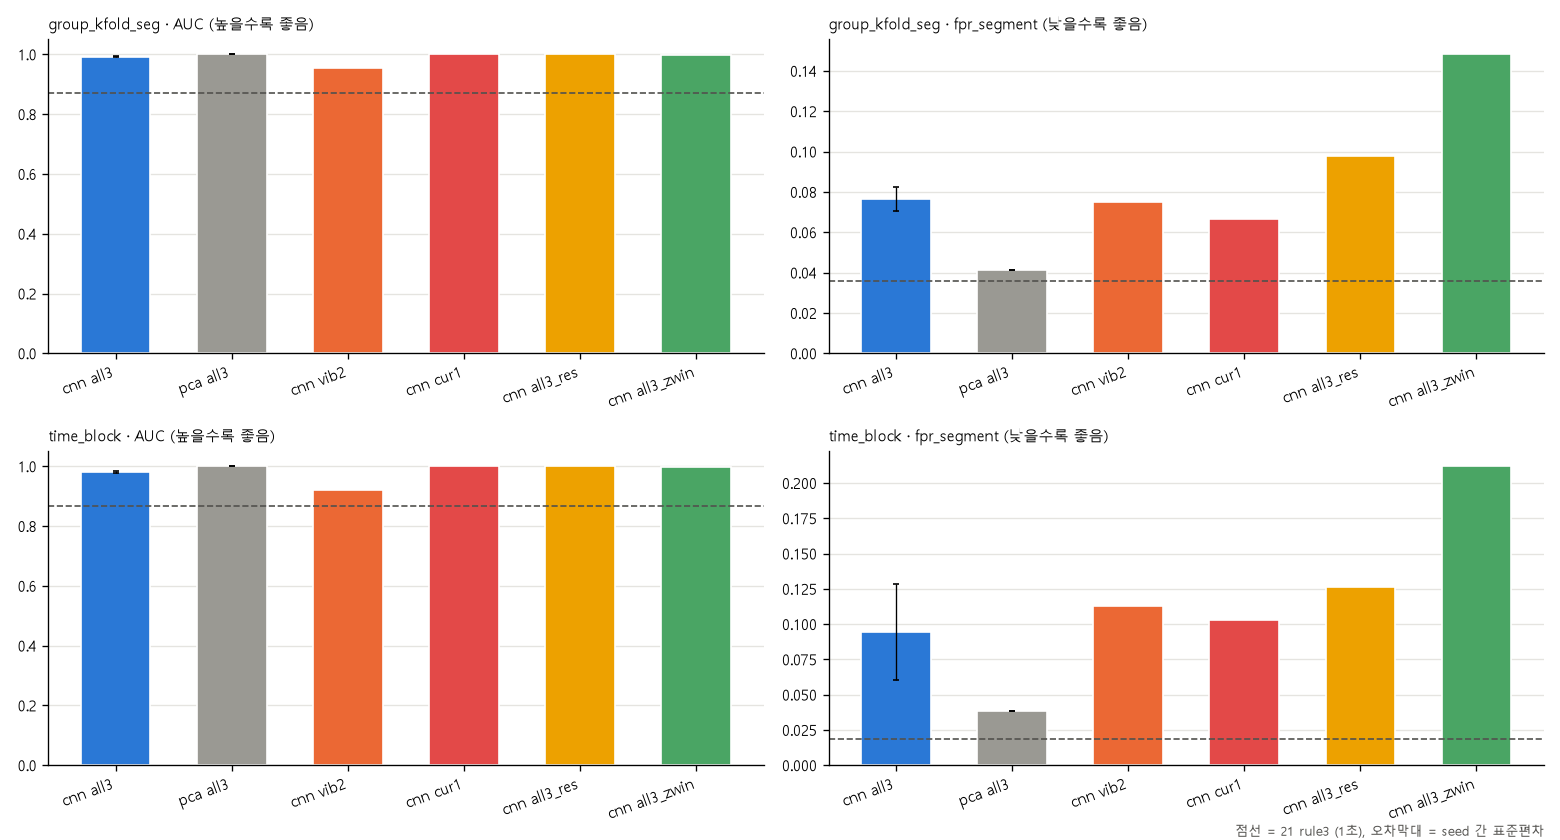

In [15]:
# (1) 변형별 AUC·fpr_segment 막대 — 1초, 두 분할, 점선 = 21 rule3
order = ["cnn_lstm_ae_all3_w1s", "pca_raw_ae_all3_w1s", "cnn_lstm_ae_vib2_w1s", "cnn_lstm_ae_cur1_w1s",
         "cnn_lstm_ae_all3_res_w1s", "cnn_lstm_ae_all3_zwin_w1s"]
base = B.baseline_table()
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for i, sp in enumerate(["group_kfold_seg", "time_block"]):
    for j, (m, ttl) in enumerate([("auc", "AUC (높을수록 좋음)"), ("fpr_segment", "fpr_segment (낮을수록 좋음)")]):
        ax = axes[i, j]
        d = cv_all[(cv_all["split"] == sp) & (cv_all["win_s"] == 1.0)]
        # 막대 = 모델별 fold·seed 평균, 오차막대 = seed별 fold 평균의 표준편차
        per = d.groupby(["model_id", "seed"])[m].mean().unstack()
        mu, sd = per.mean(1).reindex(order), per.std(1).reindex(order)
        ax.bar(range(len(order)), mu, 0.6, yerr=sd, color=["#2a78d6", "#9a9993", "#eb6834", "#e34948", "#eda100", "#4aa564"],
               edgecolor="white", error_kw={"elinewidth": 0.8, "capsize": 2})
        b = base[(base["split"] == sp) & (base["model"] == "rule3_rms_state_dir") & (base["win_s"] == 1.0)]
        if len(b):
            ax.axhline(b[m].iloc[0], color="#52514e", ls="--", lw=1)
        ax.set_xticks(range(len(order)), [o.replace("_w1s", "").replace("cnn_lstm_ae_", "cnn ") .replace("pca_raw_ae_", "pca ") for o in order], rotation=20, ha="right")
        ax.set_title(f"{sp} · {ttl}", loc="left", fontsize=9)
        ax.grid(axis="x", visible=False)
fig.text(0.99, 0.005, "점선 = 21 rule3 (1초), 오차막대 = seed 간 표준편차", fontsize=8, ha="right", color="#52514e")
fig.tight_layout(); fig.savefig(FIG / "metrics_overview.png", dpi=120); plt.close(fig)
display(Image(FIG / "metrics_overview.png"))

1초: 첫 epoch train 1.000 -> 마지막 0.159, monitor 0.151 (정규화 입력의 분산 = 1.0, 점선)
2초: 첫 epoch train 0.988 -> 마지막 0.252, monitor 0.262 (정규화 입력의 분산 = 1.0, 점선)


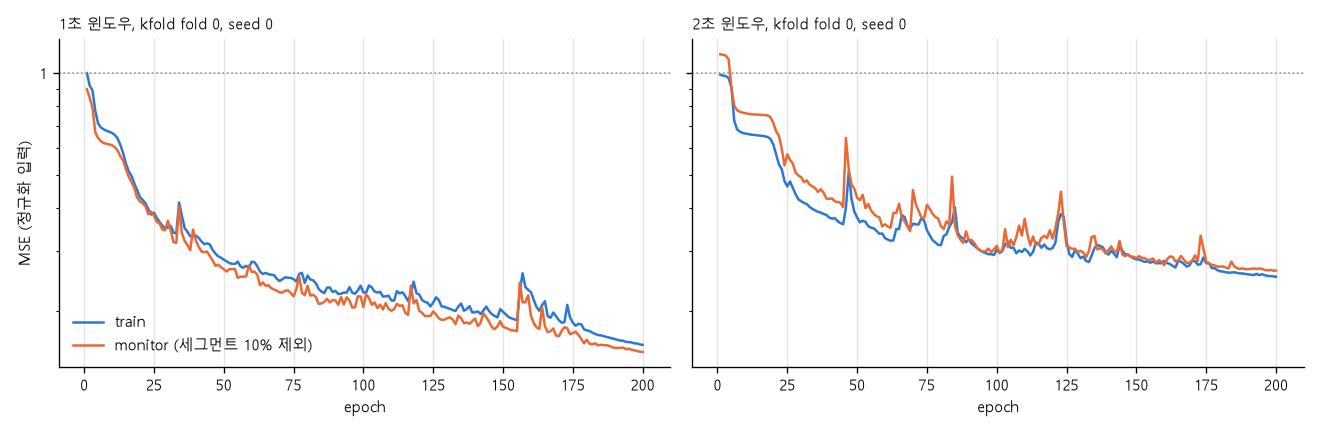

In [16]:
# (2) 손실 곡선: fold 0, seed 0 (train vs monitor)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, w in zip(axes, WIN_LIST):
    net = M.CNNLSTMAE.load(paths.MODELS / NB / f"cnn_lstm_ae_all3_w{w:g}s_group_kfold_seg_f0_s0.pt")
    h = pd.DataFrame(net.history)
    ax.plot(h["epoch"], h["train"], color="#2a78d6", label="train")
    ax.plot(h["epoch"], h["monitor"], color="#eb6834", label="monitor (세그먼트 10% 제외)")
    ax.axhline(1.0, color="#9a9993", ls=":", lw=1)
    ax.set_yscale("log"); ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}")); ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: "")); ax.set_xlabel("epoch"); ax.set_title(f"{w:g}초 윈도우, kfold fold 0, seed 0", loc="left", fontsize=9)
    print(f"{w:g}초: 첫 epoch train {h.train.iloc[0]:.3f} -> 마지막 {h.train.iloc[-1]:.3f}, monitor {h.monitor.iloc[-1]:.3f} (정규화 입력의 분산 = 1.0, 점선)")
axes[0].set_ylabel("MSE (정규화 입력)"); axes[0].legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG / "loss_curves.png", dpi=120); plt.close(fig)
display(Image(FIG / "loss_curves.png"))

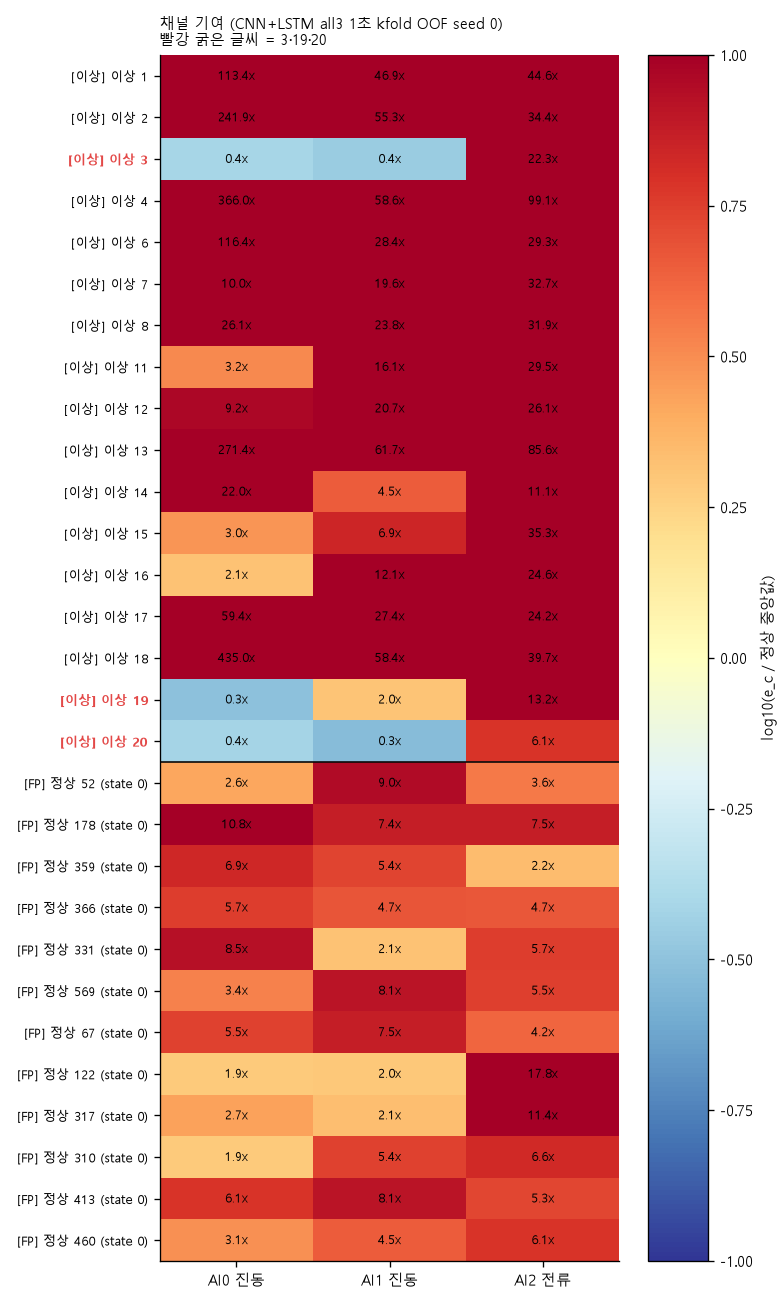

In [17]:
# (3) 채널 기여 히트맵: 이상 17 세그먼트 + FP 정상 세그먼트(초과 윈도우 많은 순 상위 12), 정상 OOF 중앙값 대비 배율(log10)
a1 = att[att.label == 1]
a0 = att[att.label == 0].sort_values("n_exceed", ascending=False).head(12)
hm = pd.concat([a1, a0])
ratio = hm[ECOLS].to_numpy() / ref_norm.to_numpy()
labels = [("[이상] " if l else "[FP] ") + u.replace("outlier_", "이상 ").replace("normal_", "정상 ") + ("" if l else f" (state {int(s)})" if s == s else "")
          for u, l, s in zip(hm.seg_uid, hm.label, hm.state)]
fig, ax = plt.subplots(figsize=(6.5, 0.32 * len(hm) + 1.6))
im = ax.imshow(np.log10(ratio), cmap="RdYlBu_r", vmin=-1, vmax=1, aspect="auto")
for i in range(ratio.shape[0]):
    for j in range(ratio.shape[1]):
        ax.text(j, i, f"{ratio[i, j]:.1f}x", ha="center", va="center", fontsize=8)
ax.set_xticks(range(3), ["AI0 진동", "AI1 진동", "AI2 전류"]); ax.set_yticks(range(len(hm)), labels, fontsize=8)
for t, u in zip(ax.get_yticklabels(), hm.seg_uid):
    if u in ("outlier_3", "outlier_19", "outlier_20"):
        t.set_color("#e34948"); t.set_fontweight("bold")
ax.axhline(len(a1) - 0.5, color="#0b0b0b", lw=1); ax.grid(False)
fig.colorbar(im, ax=ax, label="log10(e_c / 정상 중앙값)")
ax.set_title("채널 기여 (CNN+LSTM all3 1초 kfold OOF seed 0)\n빨강 굵은 글씨 = 3·19·20", loc="left", fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "channel_attribution.png", dpi=120); plt.close(fig)
display(Image(FIG / "channel_attribution.png"))

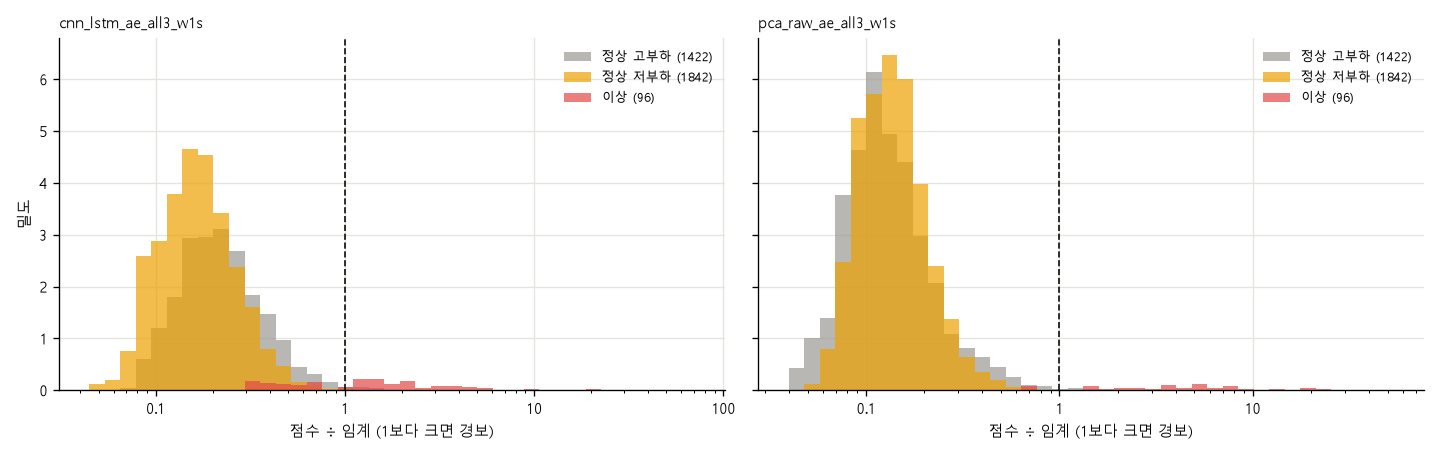

In [18]:
# (4) 점수 분포: 점수 ÷ 임계 (정상 고부하/저부하 vs 이상), 1초 kfold seed 0
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, mid in zip(axes, ["cnn_lstm_ae_all3_w1s", "pca_raw_ae_all3_w1s"]):
    s = SC[mid]; s = s[(s["split"] == "group_kfold_seg") & (s["seed"] == 0)]
    r = np.clip(s["score"] / s["thr"], 1e-2, None)
    bins = np.geomspace(max(r.min(), 1e-2), r.max(), 40)
    for lab, mask, c in [("정상 고부하", (s.label == 0) & (s.state == 0), "#9a9993"), ("정상 저부하", (s.label == 0) & (s.state == 1), "#eda100"),
                         ("이상", s.label == 1, "#e34948")]:
        ax.hist(r[mask], bins=bins, color=c, alpha=0.7, label=f"{lab} ({int(mask.sum())})", density=True)
    ax.axvline(1, color="#0b0b0b", ls="--", lw=1); ax.set_xscale("log"); ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}")); ax.xaxis.set_minor_formatter(FuncFormatter(lambda v, _: ""))
    ax.set_xlabel("점수 ÷ 임계 (1보다 크면 경보)"); ax.set_title(mid, loc="left", fontsize=9); ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("밀도")
fig.tight_layout(); fig.savefig(FIG / "score_distribution.png", dpi=120); plt.close(fig)
display(Image(FIG / "score_distribution.png"))

## 11. 결론 (성공 기준 판정, 설계서 §4)

실행 규모: CNN+LSTM 학습 90 fit(all3 1·2초 각 27 = 54 + 변형 4종 × 9분할 × seed 0 = 36) + PCA 54 run, 파라미터 15,915개(PCA는 성분 행렬 240·480). CNN+LSTM 총 학습 시간 4,871.6초(약 81분, CPU, fit당 평균 약 54초). 학습량은 epochs 200 · batch 64로 고정했다(§1의 조정 근거). 변형 4종은 seed 1개라 ablation 값에는 seed 간 분산이 없고 결론은 점추정으로만 읽는다.

| 기준 | 비교 | 수치 (1초, fold 평균, kfold / time_block) | 판정 |
|---|---|---|---|
| (a) `all3`가 `pca_raw_ae`·rule3보다 높은가 | AUC | CNN+LSTM all3 0.9927 / 0.9810, `pca_raw_ae` 0.9995 / 0.9998, rule3 0.8696 / 0.8686 | **PCA 대비 이득 없음**(−0.007 / −0.019). rule3 대비 +0.123 / +0.112는 점추정이며 쌍 차이 CI는 S4(T5)에서 검증하므로 "이득"으로 서술하지 않는다. 40 epoch 때(0.8896 / 0.9129)의 열세는 과소학습 때문이었다 |
| (b) `vib2`가 rule3을 넘는가 | AUC | vib2 0.9556 / 0.9209 vs rule3 0.8696 / 0.8686 (seed 0 한 개) | **점추정은 +0.086 / +0.052로 앞섬** → 전류 없이도 개선될 가능성(5번 소재 후보). 단 seed 1개·CI 미검증이고, 이상 17개 중 14개만 탐지(3·19·20 미탐), fpr_segment는 0.0750 / 0.1125로 rule3(0.0358 / 0.0187)보다 나쁘다 |
| (c) `cur1`만 AUC≈1.0인가 | AUC | cur1 1.0000 / 1.0000, all3_res 1.0000 / 1.0000, all3_zwin 0.9994 / 0.9983, `pca_raw_ae` 0.9995 / 0.9998, all3 0.9927 / 0.9810 | **날짜 교란 경고.** 전류 채널 하나만으로 AUC 1.0이고 전류를 포함한 입력이 모두 포화한다. 진동만(vib2)은 0.9556 / 0.9209. 이상 17 세그먼트 = 이벤트 1건, 날짜 = 라벨이므로 전류 기반 AUC 1.0은 일반화 근거가 아니다 |
| (d) fpr_segment vs rule3·PCA | fpr_segment | rule3 0.0358 / 0.0187, `pca_raw_ae` 0.0413 / 0.0381 vs all3 0.0765 / 0.0944, vib2 0.0750 / 0.1125, cur1 0.0666 / 0.1031, all3_res 0.0979 / 0.1263, all3_zwin 0.1482 / 0.2119 | **rule3·PCA보다 낮은 CNN+LSTM 변형 없음.** all3은 PCA의 약 1.9배(kfold) / 2.5배(time_block) |

주요 관찰

- 2초(평가 가능 이상 13/21 세그먼트): CNN+LSTM all3 AUC 0.9956 / 0.9944, fpr_segment 0.0637 / 0.0926; `pca_raw_ae` 1.0000 / 1.0000, 0.0395 / 0.0459. 1초와 같은 순위다.
- 손실 곡선(fold 0, seed 0): 정규화 입력의 분산이 1.0일 때 1초 train 1.000 → 0.159(monitor 0.151), 2초 0.988 → 0.252(monitor 0.262). monitor가 train과 같이 내려가 과적합 징후는 없다.
- **오경보는 고부하에 집중된다**(상태별 윈도우 fpr, kfold / time_block): CNN+LSTM all3 고부하 0.0387 / 0.0619 vs 저부하 0.0033 / 0.0028, `pca_raw_ae` 0.0210 / 0.0166 vs 0.0026 / 0.0022. FP 세그먼트(kfold seed 0)도 all3 고부하 34 / 저부하 8이다. CNN+LSTM의 fpr_segment가 PCA보다 높은 것은 고부하 정상 구간의 복원 오차 꼬리가 더 두꺼운 탓으로 보이며, 상태별 임계(고부하 전용 q99)가 4번 경보 운영 후보다. 반대로 `all3_zwin`은 저부하 0.0411 / 0.0482 vs 고부하 0.0070 / 0.0221로 오경보가 저부하로 옮겨간다(윈도우 z-score가 진폭이 작은 저부하의 형상 변동을 증폭).
- 세그먼트 집계(T2, 1초 kfold, 이상 17개): max 0.0239 / 탐지 14.3, **mean 0.0264 / 16.0**, k-of-n 1/1 0.0767 / 15.7, 2/3 0.0170 / 14.0, 3/5 0.0101 / 13.0(seed 평균). 윈도우 평균 집계가 오경보와 탐지의 균형이 가장 좋고(세그먼트 AUC 0.9934), 2/3 규칙은 fpr_segment를 0.0767 → 0.0170으로 낮추는 대신 탐지 1.7개를 잃는다. 지연(윈도우 내)은 max·1/1 0.9초, 2/3 1.4초, 3/5 1.9초이며 체감 지연은 여기에 burst 간격 7.958초가 더해진다(4번 경보 임계 소재).
- 채널 기여(T4, all3 1초 kfold seed 0): 이상 17개 중 16개 탐지(미탐은 20), 주도 채널은 AI0 9 / AI2 8이다. FP 정상 42 세그먼트의 주도 채널은 AI2 21 / AI1 12 / AI0 9로 이상 세그먼트(AI0 편중)와 달리 흩어져 있다.
- **3·19·20**: 40 epoch 때는 모두 미탐이었으나 학습량을 늘린 뒤 3은 모든 seed에서 탐지(5개 윈도우 중 4개 초과), 19는 3 seed 중 2개에서 탐지(1개 윈도우), 20은 3 seed 모두 미탐이다. 탐지된 3·19도 **진동 채널은 조용하고**(e_AI0·e_AI1은 정상 중앙값의 0.3~2.0배) **전류 채널(e_AI2)만** 정상 중앙값의 22배(3) / 13배(19), 미탐인 20은 6.1배로 임계 미달이다. 즉 이 탐지는 전류에서만 나오며 (c)의 날짜 교란과 같은 위험을 공유한다. 표준 전처리 후 AC 전류 진폭은 정상보다 낮다(21 V2-a)는 점과 복원 오차가 높다는 점이 함께 있어 원인은 진폭이 아니라 형상 차이일 수 있으나 이 노트북에서 검증하지 않았다. `vib2`는 3·19·20을 모두 놓친다(14/17).

한계

- 이상 17 세그먼트는 이벤트 1건이고 날짜 = 라벨이다. 전류가 들어간 변형의 AUC 포화는 이 이벤트에서의 관측이며 일반화 주장이 아니다. `all3+res`는 세그먼트 전체 사인 피팅 잔차라 ablation 전용이다.
- 여기서는 신뢰구간(T5)·합성 이상 주입(T6)·용량 민감도(T7)·잠재 공간(T8)·FP 의심 교집합(T9)을 하지 않았다(S4). 그래서 (a)·(b)의 우열은 점추정이다.
- 학습량(epochs 200 · batch 64)은 손실 수렴으로 정했지만 probe(fold 0 한 곳)에서 300 epoch까지 손실이 더 내려갔다(0.136). 그 이상의 학습이 지표를 더 바꿀 수 있고, 여기서는 그 경우를 보지 않았다.
- 변형 4종은 seed 0만이라 변형 간 차이가 seed 분산보다 큰지 알 수 없다. all3·`pca_raw_ae`만 seed 3개다.
- 평가 가능 범위: 1초는 이상 4/21, 2초는 8/21 세그먼트가 윈도우가 없어 제외된다.
- `pca_raw_ae`는 결정적이라 seed 3개의 값이 같다. 윈도우 간 상관과 fold별 이상 세그먼트 수(3~4개) 때문에 fold 표준편차를 신뢰구간으로 읽으면 안 된다.